In [29]:
import polars as pl
from pathlib import Path
import yaml
import plotly.express as px
import seaborn as sns
sns.set_theme()

res_files = list(Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/training_curve/').rglob('metrics.json'))

In [22]:
dfs = []
for fpath in res_files:
    df = pl.read_json(fpath)

    with open(fpath.parent/"config.yml", "r") as f:
        step = yaml.safe_load(f)['step']

    dfs.append(df.with_columns(pl.lit(step).alias('step')))

res = pl.concat(dfs,how='diagonal')
res

benchmark_name,invalid_frac,invalid_num,accuracy,model,step,precision_weighted,f1_weighted,recall_macro,precision_macro,f1_macro
str,f64,i64,f64,str,i32,f64,f64,f64,f64,f64
"""medqa_test""",0.000797,1,0.489243,"""Qwen2.5-3B-DrGRPO-Stratified-2…",2500,null,null,null,null,null
"""medqa_test""",0.0,0,0.506773,"""Qwen2.5-3B-DrGRPO-Stratified-2…",2500,null,null,null,null,null
"""medqa_test""",0.0,0,0.490837,"""Qwen2.5-3B-DrGRPO-Stratified-2…",2500,null,null,null,null,null
"""medqa_test""",0.0,0,0.500398,"""Qwen2.5-3B-DrGRPO-Stratified-2…",2500,null,null,null,null,null
"""medqa_test""",0.0,0,0.515538,"""Qwen2.5-3B-DrGRPO-Stratified-2…",2500,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…
"""test_np_one""",0.0,0,0.56383,"""Qwen2.5-3B-DrGRPO-Stratified-1…",1000,0.569219,0.547241,0.457542,0.454634,0.42779
"""test_np_one""",0.0,0,0.579787,"""Qwen2.5-3B-DrGRPO-Stratified-1…",1000,0.597404,0.566059,0.459326,0.486333,0.444475
"""test_np_one""",0.0,0,0.566489,"""Qwen2.5-3B-DrGRPO-Stratified-1…",1000,0.558454,0.543667,0.460456,0.446459,0.427385


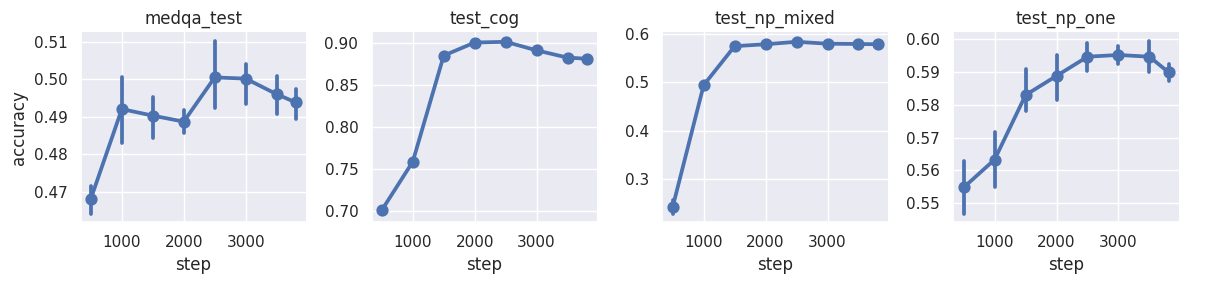

In [38]:
g = sns.catplot(
    res,
    x='step',
    y='accuracy',
    col='benchmark_name',
    kind='point',
    sharey=False,
    native_scale=True,
    height=3
)

g.set_titles(col_template='{col_name}')

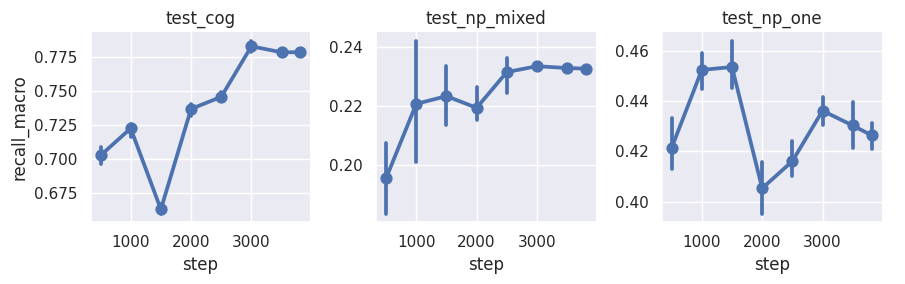

In [ ]:


g = sns.catplot(
    res.filter(pl.col('benchmark_name')!='medqa_test'),
    x='step',
    y='recall_macro',
    col='benchmark_name',
    kind='point',
    sharey=False,
    native_scale=True,
    height=3
)

g.set_titles(col_template='{col_name}')

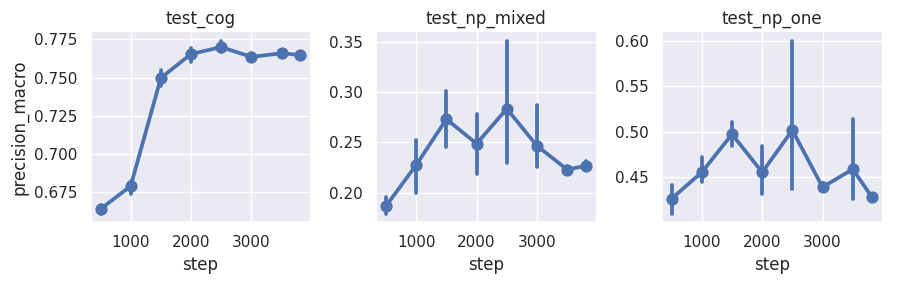

In [45]:


g = sns.catplot(
    res.filter(pl.col('benchmark_name')!='medqa_test'),
    x='step',
    y='precision_macro',
    col='benchmark_name',
    kind='point',
    sharey=False,
    native_scale=True,
    height=3
)

g.set_titles(col_template='{col_name}')

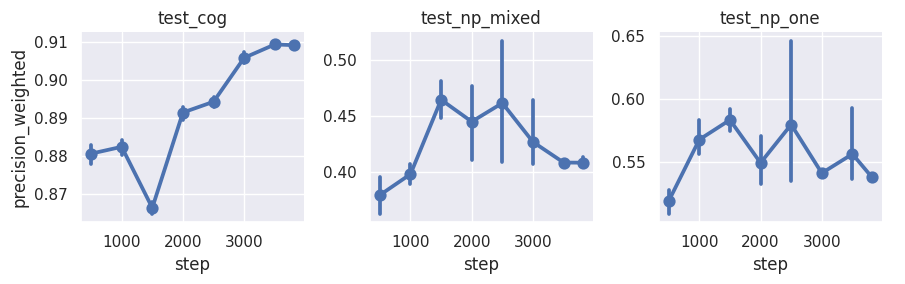

In [46]:


g = sns.catplot(
    res.filter(pl.col('benchmark_name')!='medqa_test'),
    x='step',
    y='precision_weighted',
    col='benchmark_name',
    kind='point',
    sharey=False,
    native_scale=True,
    height=3
)

g.set_titles(col_template='{col_name}')

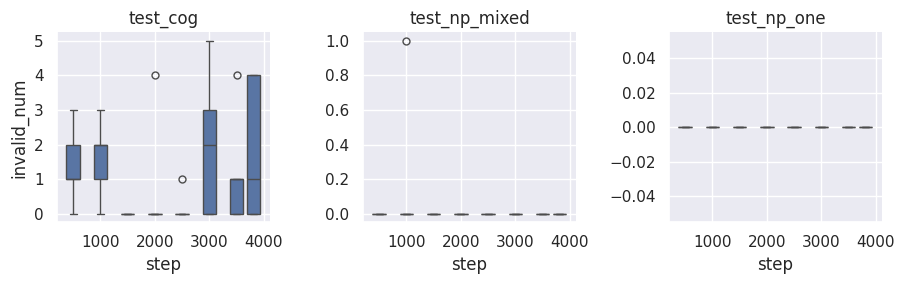

In [56]:


g = sns.catplot(
    res.filter(pl.col('benchmark_name')!='medqa_test'),
    x='step',
    y='invalid_num',
    col='benchmark_name',
    kind='box',
    sharey=False,
    native_scale=True,
    height=3
)

g.set_titles(col_template='{col_name}')